# Multi Linear Regression – Advertising Sales Prediction

**Name:** RENDLA PAVITHRA  
**ID:** 2300090355

### Objective

The aim of this analysis is to understand how TV, Radio and Newspaper advertising are related to Sales. I will use Multiple Linear Regression to predict Sales for a new advertising budget.

## 1. Import libraries

I am using pandas for the data, matplotlib for the graph and scikit-learn for the regression model.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the dataset

The CSV contains the advertising spending and the corresponding Sales values.

In [2]:
df = pd.read_csv("/mnt/data/Advertising_tuesday")
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


## 3. Check the data

First, I checked the columns, size of the dataset and whether any values are missing.

In [3]:
print("Columns:", df.columns.tolist())
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

Columns: ['TV', 'Radio', 'Newspaper', 'Sales']
Shape: (190, 4)

Missing values:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


## 4. Basic statistics

This gives a quick idea about the range and average values in each column.

In [4]:
df.describe().round(2)

,TV,Radio,Newspaper,Sales
count,190.00,190.00,190.00,190.00
mean,154.33,23.65,29.25,14.51
std,79.19,14.03,21.80,4.64
min,5.40,0.80,0.30,4.80
25%,78.20,12.22,11.15,10.60
50%,170.95,22.75,23.85,14.10
75%,225.30,36.88,42.68,17.40
max,293.60,49.60,114.00,25.50


## 5. Select the inputs and output

TV, Radio and Newspaper are the inputs. Sales is the value I want to predict.

In [5]:
X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

print("Input columns:", X.columns.tolist())
print("Target column:", y.name)

Input columns: ['TV', 'Radio', 'Newspaper']
Target column: Sales


## 6. Split the data

I used 80% of the data for training and 20% for testing. The test data is kept separate so I can check the model on data it did not learn from.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 152
Testing rows: 38


## 7. Train the model

Now I created and trained the Multiple Linear Regression model.

In [7]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


## 8. Predict Sales

The trained model is used to predict Sales for the test data.

In [8]:
y_pred = model.predict(X_test)

results = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred.round(2)
})

results.head(10)

,Actual Sales,Predicted Sales
0,13.4,14.59
1,12.6,13.27
2,13.2,15.26
3,9.3,8.43
4,20.8,20.50
5,22.4,20.76
6,10.6,12.61
7,12.5,12.96
8,10.3,12.32
9,19.8,19.61


## 9. Predict the given advertising budget

The company wants to know the expected Sales when TV = 150, Radio = 20 and Newspaper = 30.

In [9]:
new_budget = pd.DataFrame({
    "TV": [150],
    "Radio": [20],
    "Newspaper": [30]
})

prediction = model.predict(new_budget)[0]
print(f"Predicted Sales: {prediction:.2f}")

Predicted Sales: 13.73


## 10. Check model performance

I used MAE, MSE, RMSE and R² to see how close the predictions are to the actual Sales values.

In [10]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")

MAE  : 1.1753
MSE  : 3.0100
RMSE : 1.7349
R2   : 0.8606


## 11. Look at the coefficients

The coefficients show how Sales changes when one advertising value increases by one unit while the other two are kept constant.

In [11]:
coefficients = pd.DataFrame({
    "Medium": X.columns,
    "Coefficient": model.coef_
})

print("Intercept:", round(model.intercept_, 4))
coefficients.round(4)

Intercept: 3.7582


,Medium,Coefficient
0,TV,0.0424
1,Radio,0.1882
2,Newspaper,-0.0049


## 12. Find the strongest and weakest relationship

I compared the coefficient values to see which advertising medium has the largest positive relationship with Sales and which one has the smallest coefficient.

In [12]:
strongest = coefficients.loc[coefficients["Coefficient"].idxmax()]
weakest = coefficients.loc[coefficients["Coefficient"].idxmin()]

print(f"Strongest: {strongest['Medium']} ({strongest['Coefficient']:.4f})")
print(f"Least: {weakest['Medium']} ({weakest['Coefficient']:.4f})")

Strongest: Radio (0.1882)
Least: Newspaper (-0.0049)


## 13. Actual Sales vs Predicted Sales

The points should be reasonably close to the diagonal line when the predictions are close to the actual values.

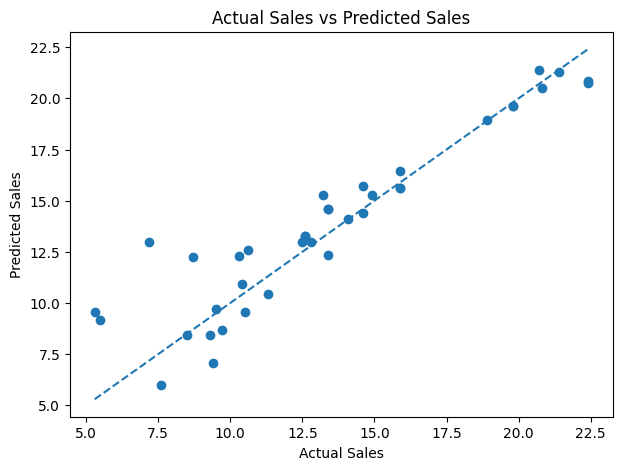

In [13]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred)

low = min(y_test.min(), y_pred.min())
high = max(y_test.max(), y_pred.max())

plt.plot([low, high], [low, high], linestyle="--")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual Sales vs Predicted Sales")
plt.show()

## 14. Final findings

**Business recommendation:** Radio has the strongest positive coefficient in this model, so the company can give more attention to Radio advertising when considering additional budget. It is still useful to compare the actual campaign cost and return before making a final budget decision.

**Technical improvement:** I would compare this model with other regression methods and use cross-validation. This can show whether a different model gives more accurate predictions.

**Prediction for the given budget:** For TV = 150, Radio = 20 and Newspaper = 30, the model predicts about **13.73 Sales units**.